### Seasonality of tracers

In [1]:
import xarray as xr

In [ ]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=1, memory_limit=15e9)
client

In [2]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()
ssh

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 161MB
Dimensions:       (x: 1260, y: 499, time_counter: 31)
Coordinates:
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
Data variables:
    sossheig      (time_counter, y, x) float64 156MB 0.1621 0.1623 ... nan nan

In [3]:
sal = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/S_*.nc').isel(deptht=0)
# sal = sal.compute()

sal_ds = xr.Dataset(
    data_vars={
        'so': (('time','lat','lon'), sal.vosaline.data),
    },
    coords={
        'time':sal.time_counter.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
sal_ds

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 6209, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 50kB 1993-01-01T12:00:00 ... 2009-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    so       (time, lat, lon) float32 16GB dask.array<chunksize=(1, 208, 1260), meta=np.ndarray>

In [6]:
def monthly_climatology(da):
    return da.groupby('time.month').mean('time')

def daily_monthly_anomaly(da):
    clim = monthly_climatology(da)
    return da.groupby('time.month') - clim

In [7]:
so_clim = monthly_climatology(sal_ds.so)
so_anom = daily_monthly_anomaly(sal_ds.so)

In [13]:
# so_anom.to_netcdf('Sal_d_anom.nc')

In [2]:
sal_anom = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/Sal_d_anom.nc')
sal_anom = sal_anom.compute()
sal_anom

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 6209, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 50kB 1993-01-01T12:00:00 ... 2009-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
    month    (time) int64 50kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12
Data variables:
    so       (time, lat, lon) float32 16GB 0.2602 0.2422 0.2394 ... nan nan nan

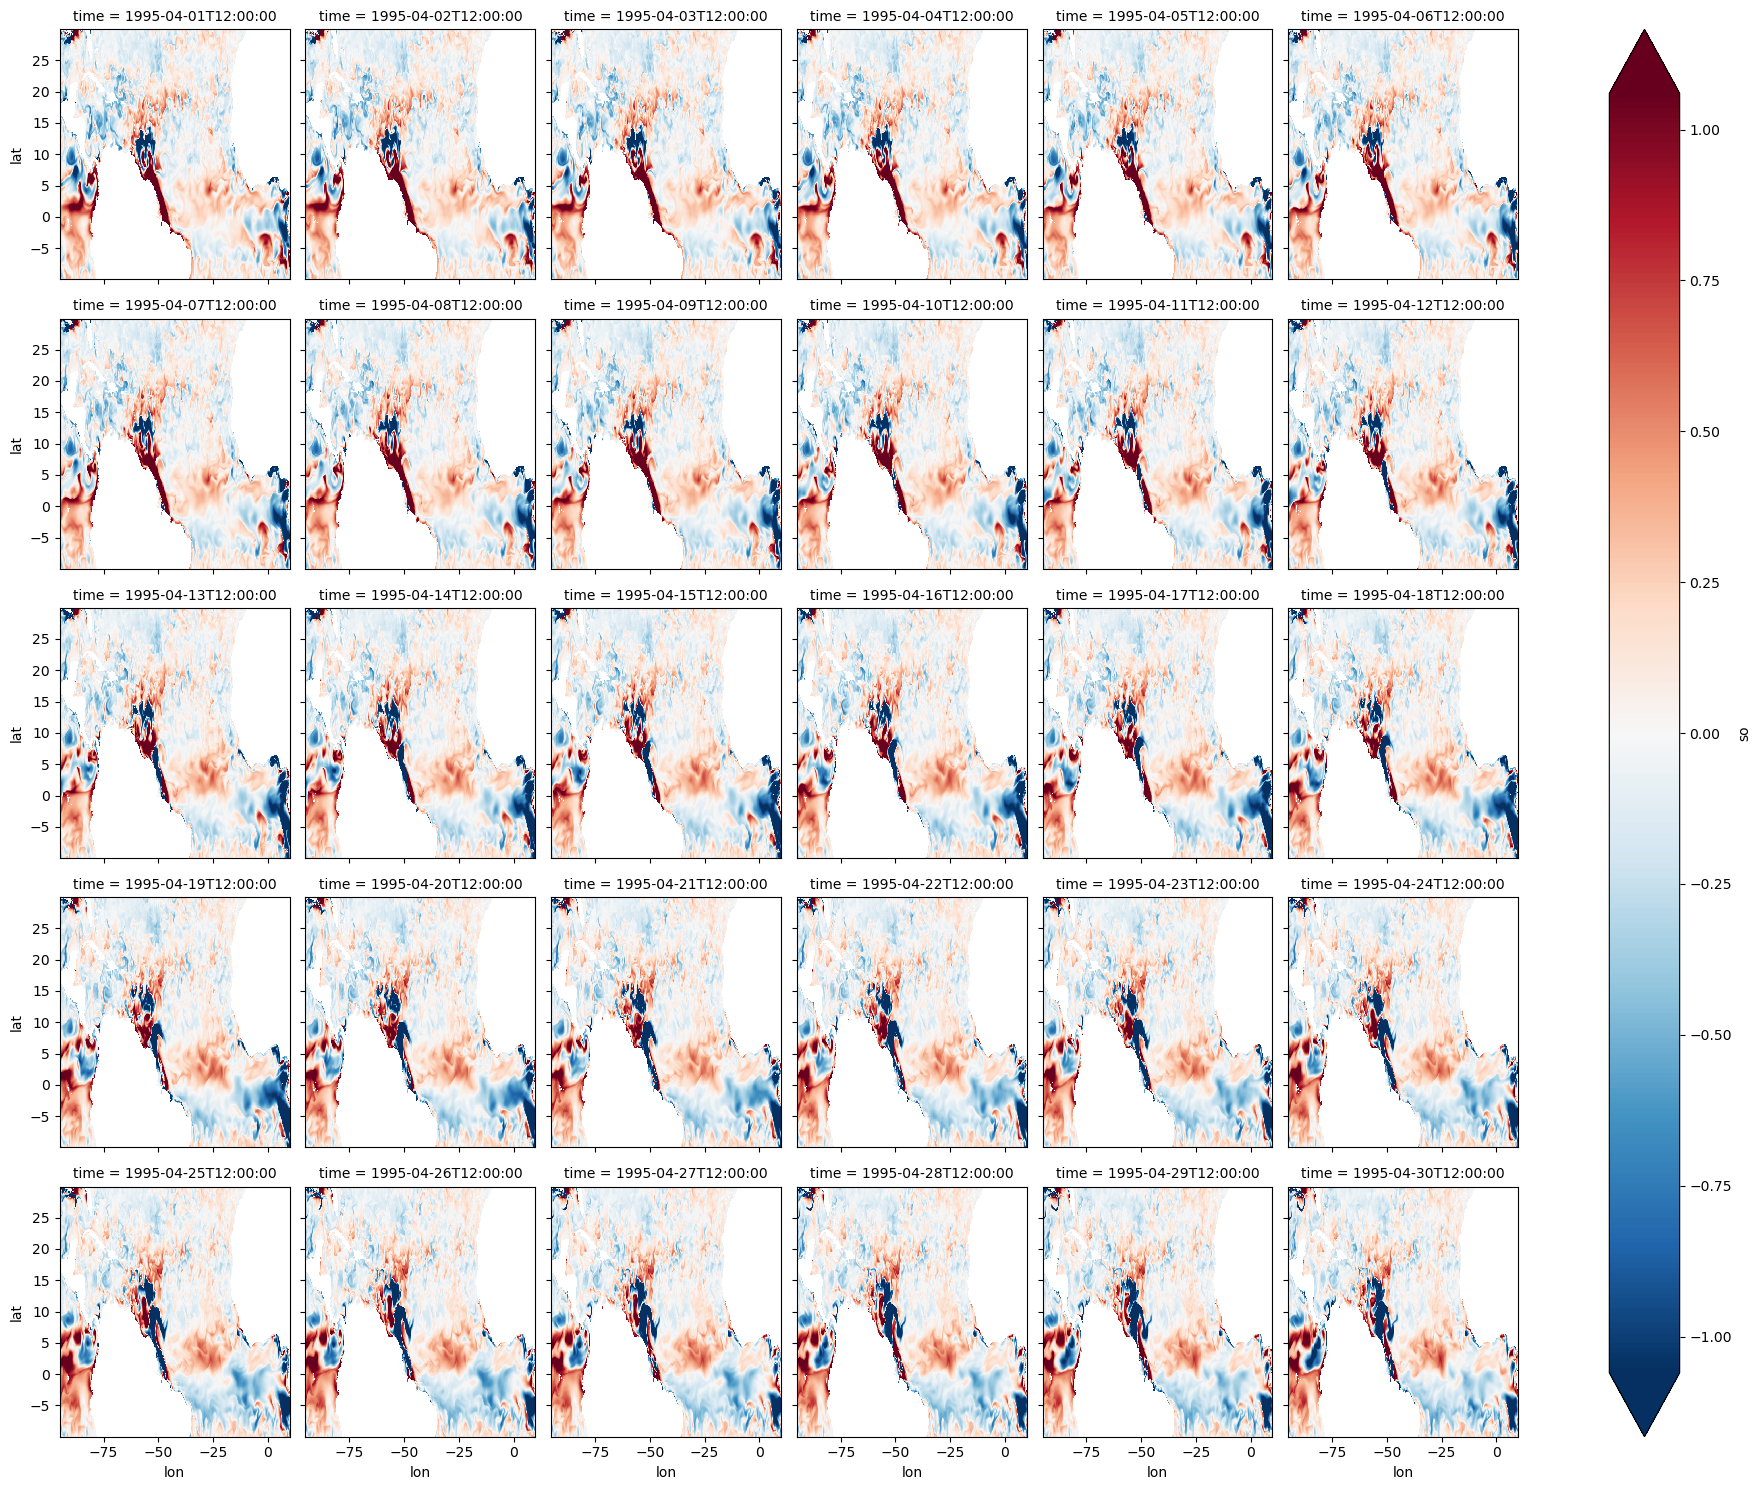

In [6]:
sal_anom.so.sel(
    time=slice('1995-04-01','1995-04-30')).plot(col='time',col_wrap=6,robust=True)

* Just a thought. When there is more freshwater coming out of the ARP (salinity anomalies), then there's generation of eddies (density gradient change --> fronts --> shear --> eddies --> ARP deflected to the SouthWest)